# Visualization Examples
This notebook contains simple examples (with code) for:

1. 3D visualization: surfaces, contours, hidden surfaces, 3D mapping
2. Multi-dimensional data visualization: scatter-matrix, parallel coordinates, PCA
3. Manifold visualization: Swiss roll and Isomap / t-SNE
4. Graph data visualization: NetworkX examples
5. Annotation: marking points on plots



In [ ]:
# Imports used across examples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers projection
from matplotlib import cm  # Imports colormaps (like 'viridis', 'plasma') for better visualization.
import seaborn as sns      # only for nicer dataframe display (optional)
import networkx as nx      # Library for graph data visualization and analysis.

from sklearn import decomposition, datasets, manifold
from sklearn.datasets import make_swiss_roll, make_blobs
from sklearn.manifold import Isomap, TSNE
from sklearn.decomposition import PCA

%matplotlib inline
plt.rcParams['figure.figsize'] = (7,5)


1️⃣ import numpy as np

Purpose: For numerical operations (arrays, mesh grids, etc.)

Example Use:

X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))


Used in 3D surface/contour plots.

2️⃣ import pandas as pd

Purpose: To handle tabular data easily.

Example Use:

df = pd.DataFrame({
    'x': [1,2,3],
    'y': [4,5,6],
    'z': [7,8,9]
})


Used in multi-dimensional or scatterplot matrix visualizations.

3️⃣ import matplotlib.pyplot as plt

Purpose: The main plotting library for 2D and 3D charts.

Example:

plt.plot([1,2,3], [2,4,6])
plt.show()


4️⃣ from mpl_toolkits.mplot3d import Axes3D

Purpose: Enables 3D plotting support in Matplotlib.
(Registers the "3d" projection type.)

Example:

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


Used in 3D surface and contour plots.


5️⃣ from matplotlib import cm

Purpose: Imports colormaps (like 'viridis', 'plasma') for better visualization.

Example:

ax.plot_surface(X, Y, Z, cmap=cm.plasma)

Used in colorful 3D surface visualization.

6️⃣ import seaborn as sns

Purpose: High-level visualization library built on top of Matplotlib.

Use: For scatter matrix, heatmaps, or better styling.

Example:

sns.pairplot(df, hue='species')


Used in multi-dimensional visualization (Iris dataset).

7️⃣ import networkx as nx

Purpose: Library for graph data visualization and analysis.

Example:

G = nx.karate_club_graph()
nx.draw(G, with_labels=True)
plt.show()


Used in graph visualization topics..

8️⃣ from sklearn import decomposition, datasets, manifold

Purpose: Imports scikit-learn submodules used for:

datasets → load sample datasets (Iris, Swiss Roll)

decomposition → PCA (Principal Component Analysis)

manifold → Isomap, LLE, t-SNE (manifold learning)

Example:

X, _ = datasets.make_swiss_roll(n_samples=1000)


9️⃣ from sklearn.datasets import make_swiss_roll, make_blobs

Purpose: Functions to generate synthetic data for visualization.

Examples:

make_swiss_roll() → for manifold visualization

make_blobs() → for clustering visualization

X, color = make_swiss_roll(n_samples=1000)


🔟 from sklearn.manifold import Isomap, TSNE

Purpose:

Isomap → preserves global geometry (for manifold visualization)

t-SNE → preserves local cluster structure (for dimensionality reduction visualization)

Example:

X_iso = Isomap(n_components=2).fit_transform(X)
X_tsne = TSNE(n_components=2).fit_transform(X)

1️⃣1️⃣ from sklearn.decomposition import PCA

Purpose:
Performs Principal Component Analysis for dimensionality reduction.

Example:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1])

1️⃣2️⃣ %matplotlib inline

Purpose:
Used in Jupyter Notebook — ensures that all plots are displayed directly in the notebook.

1️⃣3️⃣ plt.rcParams['figure.figsize'] = (7,5)

Purpose:
Sets the default plot size for all figures to 7×5 inches for consistency.

## 1) 3D Visualization: Surface, Contours, Hidden Surfaces, 3D Mapping
We create a sample surface z = sin(r)/r and show:
- a 3D surface
- a contour projection
- change view (`view_init`) to demonstrate occlusion/hidden-surface perception


In [27]:
import numpy as np
# Create grid and surface
x = np.linspace(-6, 6, 80)
y = np.linspace(-6, 6, 80)

print(x)

print(y)

[-6.         -5.84810127 -5.69620253 -5.5443038  -5.39240506 -5.24050633
 -5.08860759 -4.93670886 -4.78481013 -4.63291139 -4.48101266 -4.32911392
 -4.17721519 -4.02531646 -3.87341772 -3.72151899 -3.56962025 -3.41772152
 -3.26582278 -3.11392405 -2.96202532 -2.81012658 -2.65822785 -2.50632911
 -2.35443038 -2.20253165 -2.05063291 -1.89873418 -1.74683544 -1.59493671
 -1.44303797 -1.29113924 -1.13924051 -0.98734177 -0.83544304 -0.6835443
 -0.53164557 -0.37974684 -0.2278481  -0.07594937  0.07594937  0.2278481
  0.37974684  0.53164557  0.6835443   0.83544304  0.98734177  1.13924051
  1.29113924  1.44303797  1.59493671  1.74683544  1.89873418  2.05063291
  2.20253165  2.35443038  2.50632911  2.65822785  2.81012658  2.96202532
  3.11392405  3.26582278  3.41772152  3.56962025  3.72151899  3.87341772
  4.02531646  4.17721519  4.32911392  4.48101266  4.63291139  4.78481013
  4.93670886  5.08860759  5.24050633  5.39240506  5.5443038   5.69620253
  5.84810127  6.        ]
[-6.         -5.84810127 -5

In [29]:
X, Y = np.meshgrid(x, y)
print(X)
print(Y)

[[-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]
 [-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]
 [-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]
 ...
 [-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]
 [-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]
 [-6.         -5.84810127 -5.69620253 ...  5.69620253  5.84810127
   6.        ]]
[[-6.         -6.         -6.         ... -6.         -6.
  -6.        ]
 [-5.84810127 -5.84810127 -5.84810127 ... -5.84810127 -5.84810127
  -5.84810127]
 [-5.69620253 -5.69620253 -5.69620253 ... -5.69620253 -5.69620253
  -5.69620253]
 ...
 [ 5.69620253  5.69620253  5.69620253 ...  5.69620253  5.69620253
   5.69620253]
 [ 5.84810127  5.84810127  5.84810127 ...  5.84810127  5.84810127
   5.84810127]
 [ 6.          6.          6.         ...  6.          6.
   6.        ]]


In [30]:
R = np.sqrt(X**2 + Y**2) + 1e-6
print(R)

[[8.48528237 8.37856224 8.27325449 ... 8.27325449 8.37856224 8.48528237]
 [8.37856224 8.27046512 8.1637631  ... 8.1637631  8.27046512 8.37856224]
 [8.27325449 8.1637631  8.05564787 ... 8.05564787 8.1637631  8.27325449]
 ...
 [8.27325449 8.1637631  8.05564787 ... 8.05564787 8.1637631  8.27325449]
 [8.37856224 8.27046512 8.1637631  ... 8.1637631  8.27046512 8.37856224]
 [8.48528237 8.37856224 8.27325449 ... 8.27325449 8.37856224 8.48528237]]


In [40]:

Z = np.sin(R) / R
print(Z)
print(Z.shape)

[[0.09513655 0.10330341 0.11040216 ... 0.11040216 0.10330341 0.09513655]
 [0.10330341 0.11057627 0.11666191 ... 0.11666191 0.11057627 0.10330341]
 [0.11040216 0.11666191 0.12162078 ... 0.12162078 0.11666191 0.11040216]
 ...
 [0.11040216 0.11666191 0.12162078 ... 0.12162078 0.11666191 0.11040216]
 [0.10330341 0.11057627 0.11666191 ... 0.11666191 0.11057627 0.10330341]
 [0.09513655 0.10330341 0.11040216 ... 0.11040216 0.10330341 0.09513655]]
(80, 80)


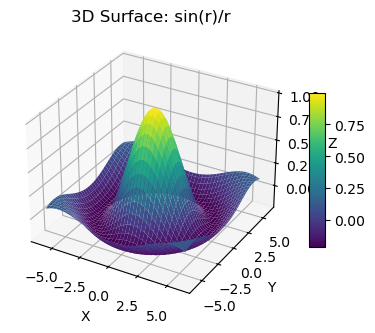

In [38]:
import matplotlib.pyplot as plt 
# 3D surface plot
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=True)
ax1.set_title('3D Surface: sin(r)/r')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
plt.show()

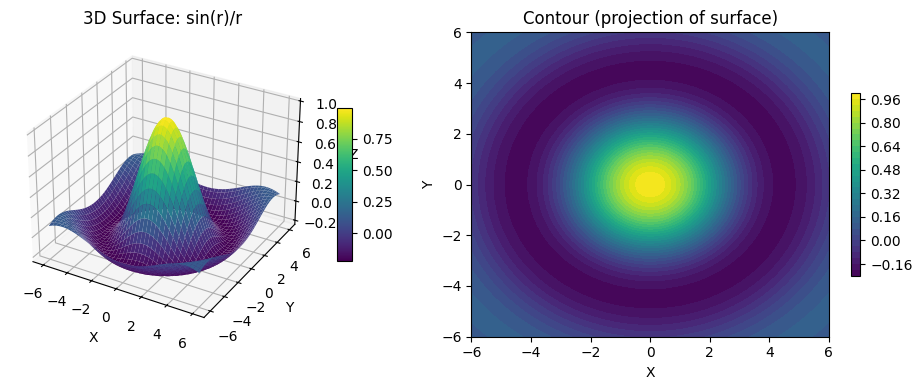

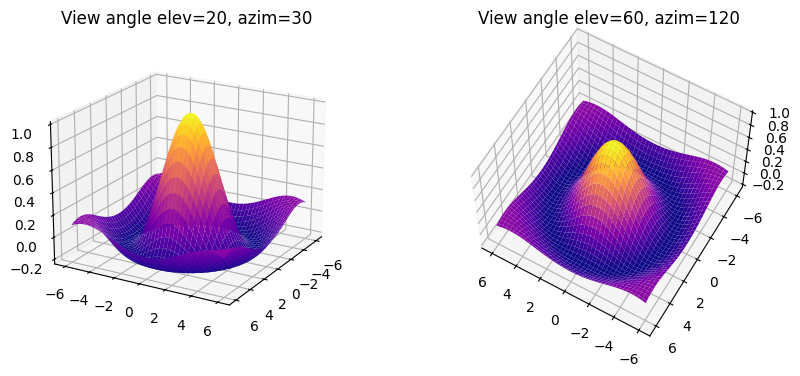

In [ ]:
# Create grid and surface
x = np.linspace(-6, 6, 80)
y = np.linspace(-6, 6, 80)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2) + 1e-6
Z = np.sin(R) / R

# 3D surface plot
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=True)
ax1.set_title('3D Surface: sin(r)/r')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Contour projection (contourf on the right)
ax2 = fig.add_subplot(1,2,2)
cf = ax2.contourf(X, Y, Z, levels=30, cmap='viridis')
ax2.set_title('Contour (projection of surface)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
fig.colorbar(cf, ax=ax2, shrink=0.6)
plt.tight_layout()
plt.show()

# Demonstrate hidden-surface perception by changing view angle
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,2,1, projection='3d')
ax.plot_surface(X, Y, Z, cmap=cm.plasma, rstride=2, cstride=2, linewidth=0, antialiased=True)
ax.view_init(elev=20, azim=30)
ax.set_title('View angle elev=20, azim=30')

axb = fig.add_subplot(1,2,2, projection='3d')
axb.plot_surface(X, Y, Z, cmap=cm.plasma, rstride=2, cstride=2, linewidth=0, antialiased=True)
axb.view_init(elev=60, azim=120)  # different angle -> different occluded parts
axb.set_title('View angle elev=60, azim=120')
plt.show()


## 2) Multi-dimensional Visualization
Examples:
- Scatterplot matrix (pairplot)
- Parallel coordinates
- PCA projection to 2D for visualization

We'll use the Iris dataset (classic) and also a synthetic 5-d dataset.

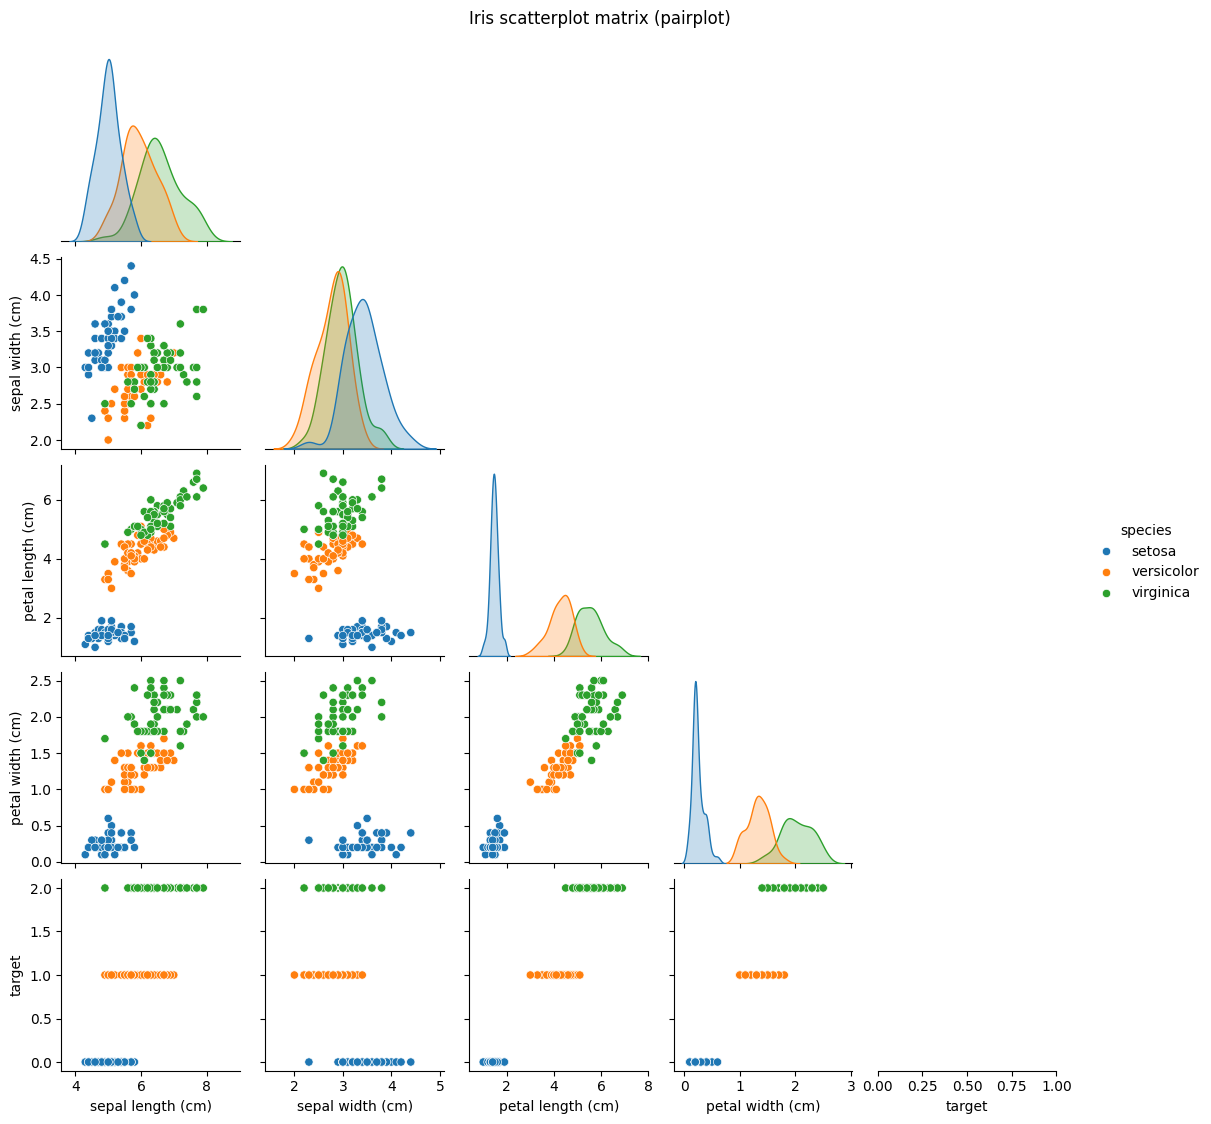

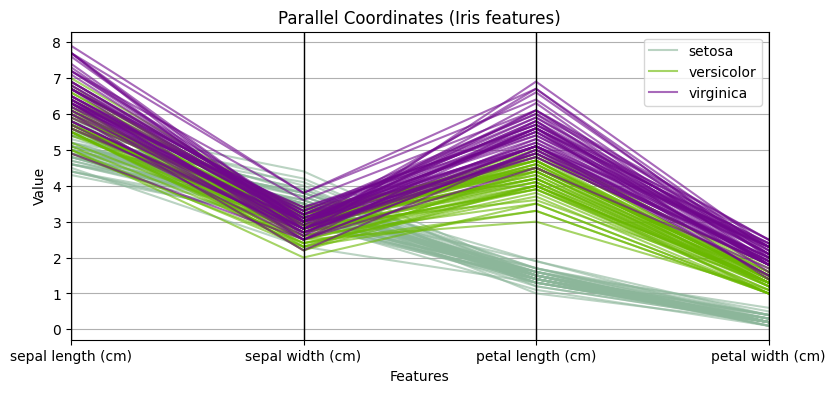

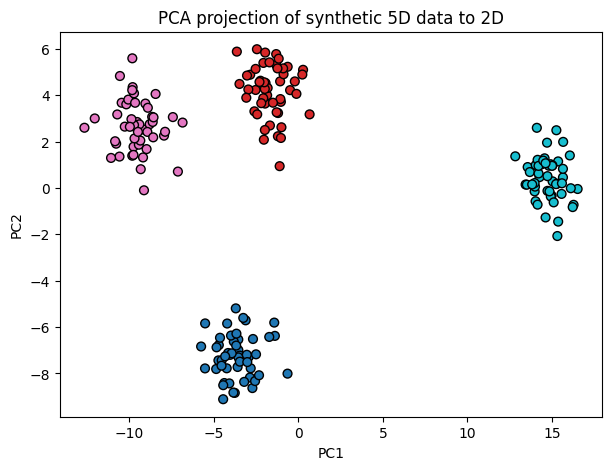

In [ ]:
# Load Iris dataset for pairplot and PCA
iris = datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Scatterplot matrix (pairplot) using seaborn for clarity (still Matplotlib backend)
sns.pairplot(df_iris, hue='species', corner=True, height=2.2)
plt.suptitle('Iris scatterplot matrix (pairplot)', y=1.02)
plt.show()

# Parallel coordinates example (requires DataFrame with class column)
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(9,4))
parallel_coordinates(df_iris[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)','species']], 'species', alpha=0.6)
plt.title('Parallel Coordinates (Iris features)')
plt.xlabel('Features'); plt.ylabel('Value')
plt.show()

# PCA projection of a synthetic 5-D dataset
rng = np.random.RandomState(0)
X, y = make_blobs(n_samples=200, centers=4, n_features=5, random_state=rng)
pca = PCA(n_components=2)
Xp = pca.fit_transform(X)
plt.scatter(Xp[:,0], Xp[:,1], c=y, cmap='tab10', s=40, edgecolor='k')
plt.title('PCA projection of synthetic 5D data to 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


## 3) Manifold Visualization
Use the Swiss Roll dataset to show how nonlinear methods (Isomap, t-SNE) can 'unfold' a manifold.

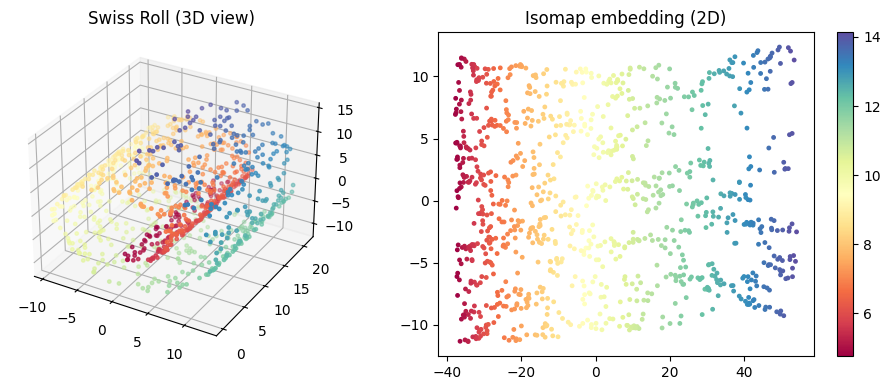

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


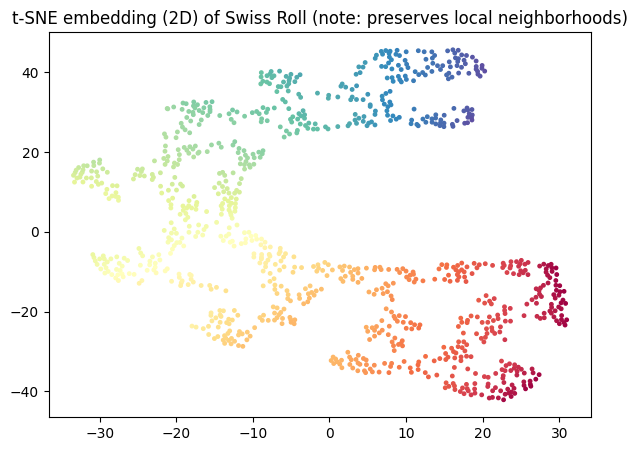

In [10]:
# Generate Swiss roll
X, color = make_swiss_roll(n_samples=1000, noise=0.05, random_state=42)

# 3D scatter of swiss roll
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,2,1, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=color, cmap=plt.cm.Spectral, s=6)
ax.set_title('Swiss Roll (3D view)')

# Isomap (unfold)
iso = Isomap(n_components=2, n_neighbors=10)
X_iso = iso.fit_transform(X)
ax2 = fig.add_subplot(1,2,2)
sc = ax2.scatter(X_iso[:,0], X_iso[:,1], c=color, cmap=plt.cm.Spectral, s=6)
ax2.set_title('Isomap embedding (2D)')
plt.colorbar(sc, ax=ax2)
plt.tight_layout()
plt.show()

# t-SNE (slower, but useful for clusters/local structure)
tsne = TSNE(n_components=2, init='pca', random_state=0, perplexity=30, learning_rate=200, n_iter=1000)
X_tsne = tsne.fit_transform(X)
plt.figure()
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=color, cmap=plt.cm.Spectral, s=6)
plt.title('t-SNE embedding (2D) of Swiss Roll (note: preserves local neighborhoods)')
plt.show()


## 4) Graph Data Visualization
Create a small synthetic graph (e.g., social network) and visualize with different layouts.

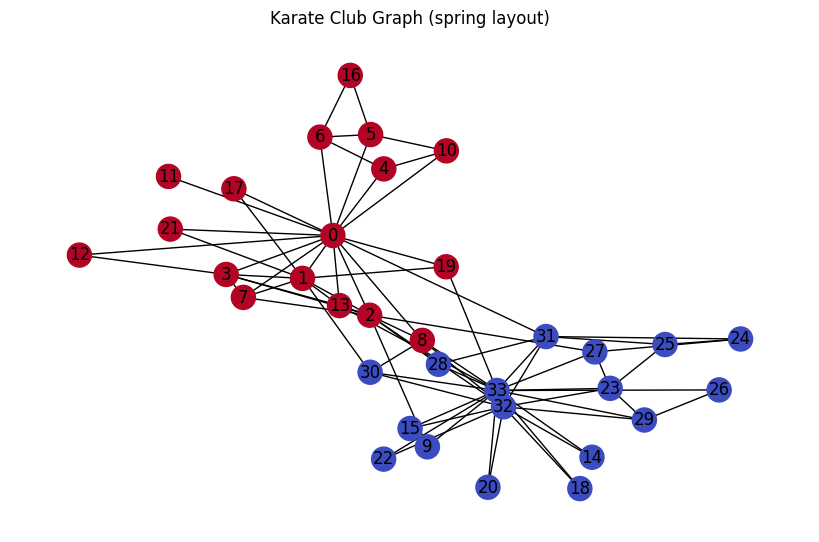

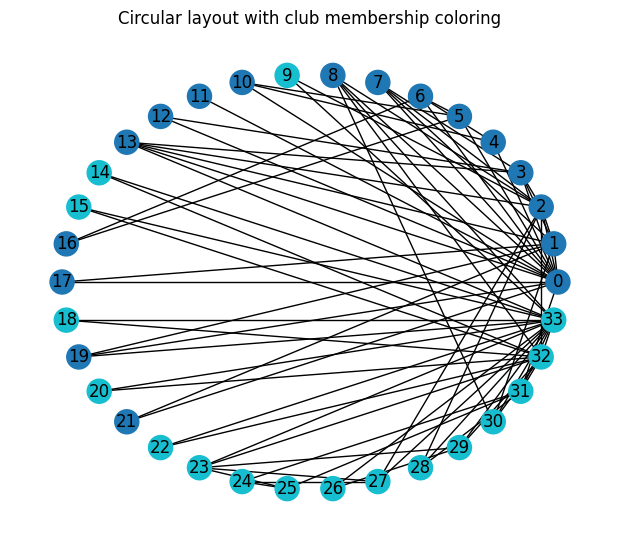

In [ ]:
# Create a sample graph (Zachary's Karate Club is included with NetworkX)
G = nx.karate_club_graph()

# Force-directed layout (spring layout)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,5))
nx.draw(G, pos, with_labels=True, node_color=[G.nodes[n]['club']=='Mr. Hi' for n in G.nodes()], cmap='coolwarm', node_size=300)
plt.title('Karate Club Graph (spring layout)')
plt.show()

# Circular layout and highlighting communities (using built-in attribute 'club' as group)
plt.figure(figsize=(6,5))
pos_circ = nx.circular_layout(G)
clubs = [0 if G.nodes[n]['club']=='Mr. Hi' else 1 for n in G.nodes()]
nx.draw(G, pos_circ, node_color=clubs, with_labels=True, node_size=300, cmap='tab10')
plt.title('Circular layout with club membership coloring')
plt.show()


## 5) Annotation
Simple example: annotate the maximum point on a noisy sine wave.

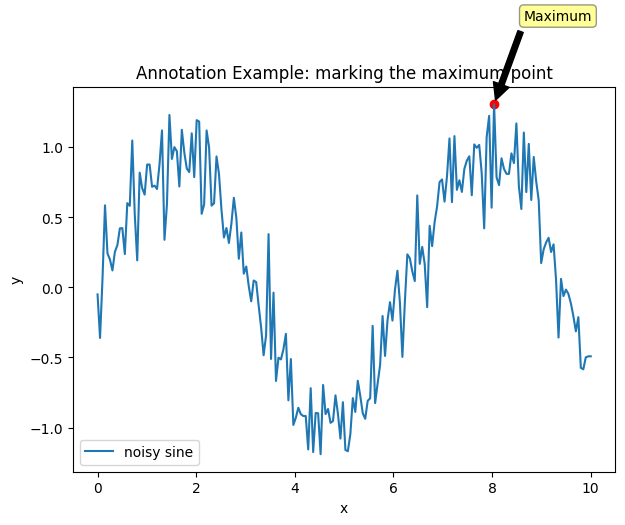

In [12]:
x = np.linspace(0, 10, 200)
y = np.sin(x) + 0.2*np.random.randn(len(x))

plt.plot(x, y, label='noisy sine')
imax = np.argmax(y)
plt.scatter([x[imax]], [y[imax]], color='red')
plt.annotate('Maximum', xy=(x[imax], y[imax]), xytext=(x[imax]+0.6, y[imax]+0.6),
             arrowprops=dict(facecolor='black', shrink=0.05), bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.4))
plt.title('Annotation Example: marking the maximum point')
plt.xlabel('x'); plt.ylabel('y')
plt.legend()
plt.show()
